In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import matplotlib.pyplot as plt

/Users/seongyeon/Desktop/Study/cs6713/comp6713-veil/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Pre-processing

# Put all data together
df = pd.concat([
    pd.read_csv("../data/processed/sentiment/fmb_standardized.csv"),
    pd.read_csv("../data/processed/sentiment/fpb_standardized.csv"), 
    pd.read_csv("../data/processed/sentiment/stitched_sentiment.csv"),
], ignore_index=True)

df['sentiment'] = df['sentiment'].astype(str).str.lower().str.strip()
df = df.dropna(subset=['sentiment'])

# Split data
train_val, test = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['sentiment'],
)

train, val = train_test_split(
    train_val, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_val['sentiment']
)
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 16605, Val: 4152, Test: 5190


In [ ]:
# Tokenize
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

label_map = {"negative": 0, "neutral": 1, "positive": 2}
train['label'] = train['sentiment'].map(label_map)
val['label'] = val['sentiment'].map(label_map)
test['label'] = test['sentiment'].map(label_map)

class FinancialDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = str(self.data.iloc[idx]['data'])
        label = self.data.iloc[idx]['label']

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = FinancialDataset(train, tokenizer)
val_dataset = FinancialDataset(val, tokenizer)
test_dataset = FinancialDataset(test, tokenizer)

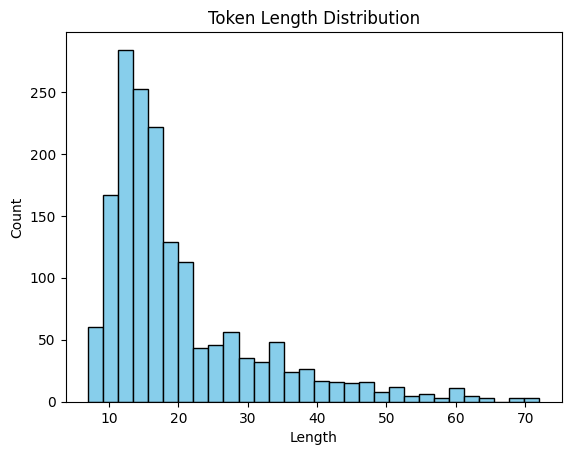

In [4]:
token_lens = [len(tokenizer.encode(str(txt))) for txt in train['data'].sample(frac=0.1)] # 10%만 샘플링해서 확인

plt.hist(token_lens, bins=30, color='skyblue', edgecolor='black')
plt.title('Token Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

In [5]:
!pip install 'accelerate>=1.1.0'

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=3
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=10,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 74199.53it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
trainer.train()

history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(range(0, len(train_loss), len(train_loss)//len(eval_loss)), eval_loss, label='Val Loss') # 주기에 맞춰 보정
plt.title('Training & Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eval_acc, label='Val Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.legend()

plt.show()

/Users/seongyeon/Desktop/Study/cs6713/comp6713-veil/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
0,0.321567,0.604367,0.791715,0.790585


KeyboardInterrupt: 

In [ ]:
save_directory = "./my_finbert_model"
trainer.save_model(save_directory)

tokenizer.save_pretrained(save_directory)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.62it/s]

학습 완료된 모델이 './my_finbert_model'에 저장되었습니다.


In [ ]:
import json
import glob
import os

state_files = glob.glob("./results/checkpoint-*/trainer_state.json")

if state_files:
    latest_state = max(state_files, key=os.path.getmtime)
    print(f"Files to call: {latest_state}")
    
    with open(latest_state, 'r') as f:
        state_data = json.load(f)
    
    trainer.state.log_history = state_data['log_history']
else:
    print("Cannot Find")

복구할 파일: ./results/checkpoint-3114/trainer_state.json
기록 복구 완료! 이제 다시 그래프 함수를 실행해보세요.


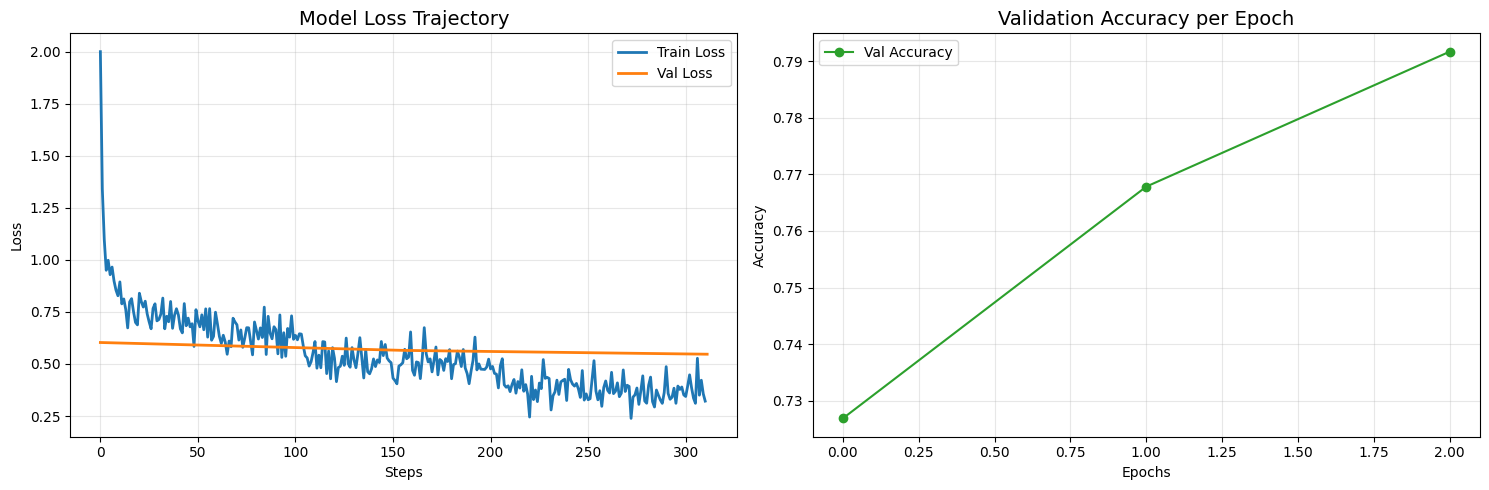

In [ ]:
def save_training_report(trainer, save_path="./report"):
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    history = trainer.state.log_history
    
    # 데이터 추출
    train_loss = [x['loss'] for x in history if 'loss' in x]
    eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
    eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
    
    plt.figure(figsize=(15, 5))
    
    # 1. Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(np.linspace(0, len(train_loss), len(eval_loss)), eval_loss, label='Val Loss', color='#ff7f0e', lw=2)
    plt.title('Model Loss Trajectory', fontsize=14)
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(eval_acc, label='Val Accuracy', color='#2ca02c', marker='o')
    plt.title('Validation Accuracy per Epoch', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/learning_curve.png", dpi=300)
    plt.show()

save_training_report(trainer)

/Users/seongyeon/Desktop/Study/cs6713/comp6713-veil/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


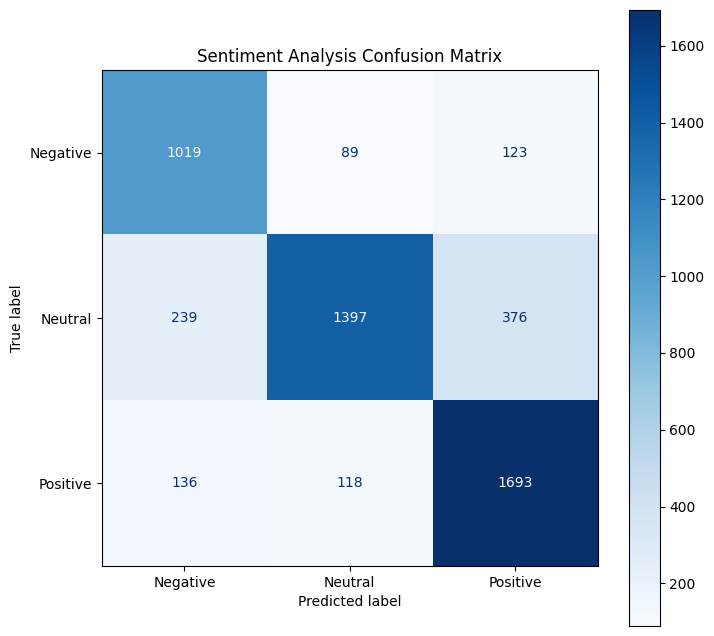

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def save_confusion_matrix(trainer, test_dataset, save_path="./report"):
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = predictions.label_ids
    
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Negative", "Neutral", "Positive"]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title('Sentiment Analysis Confusion Matrix')
    
    plt.savefig(f"{save_path}/confusion_matrix.png", dpi=300)
    plt.show()

save_confusion_matrix(trainer, test_dataset)

In [ ]:
test_results = trainer.evaluate(test_dataset)
df_results = pd.DataFrame([test_results])
df_results.to_csv("./report/final_metrics.csv", index=False)

/Users/seongyeon/Desktop/Study/cs6713/comp6713-veil/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
